# Phase 4.1: Advanced Visualizations & Model Evaluation
In this notebook, we will generate the 5 most important visualizations for a regression project. 
This helps us deeply understand the data parameters and diagnose how our model is actually performing beyond just looking at the MAE score.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.model_selection import train_test_split

plt.style.use('ggplot')

# Load the processed dataset
df = pd.read_csv('../data/processed/engineered_running_times.csv')
print("Data Loaded!")

Data Loaded!


## Part 1: Understanding the Data Parameters

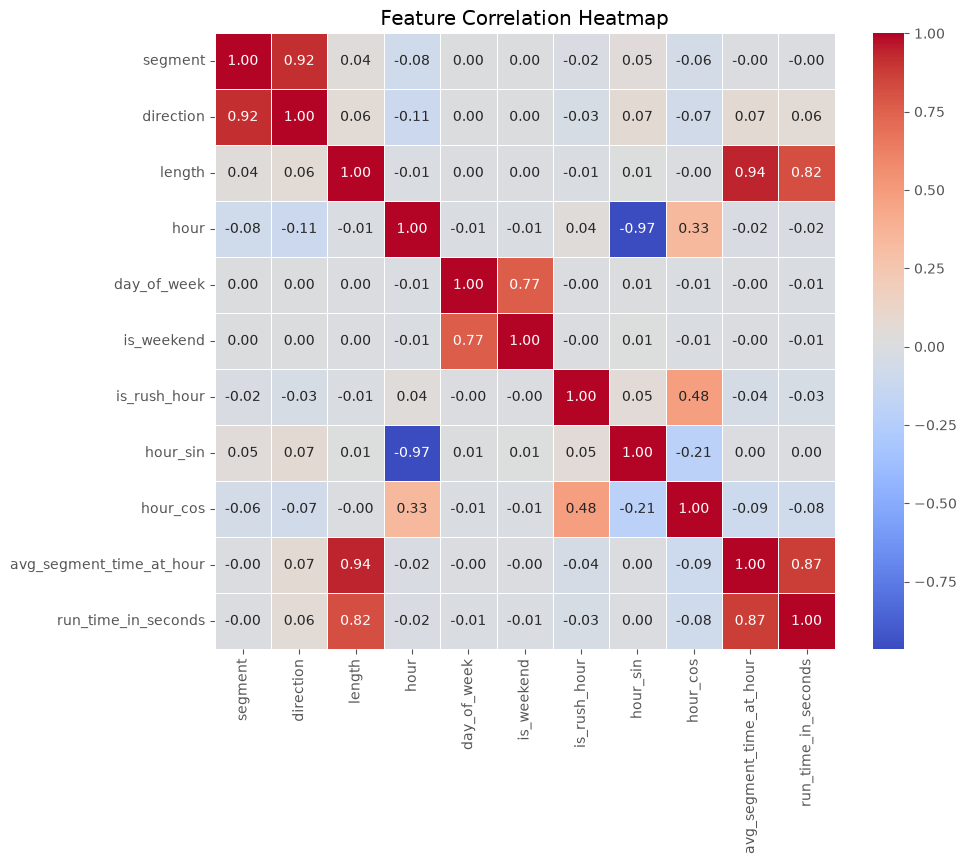

In [2]:
# 1. Correlation Heatmap
plt.figure(figsize=(10, 8))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.show()

/var/folders/yp/bdvkdlmn2_s8lnsffzcwm1bc0000gn/T/ipykernel_86298/2800225234.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='hour', y='run_time_in_seconds', data=df, palette='viridis')


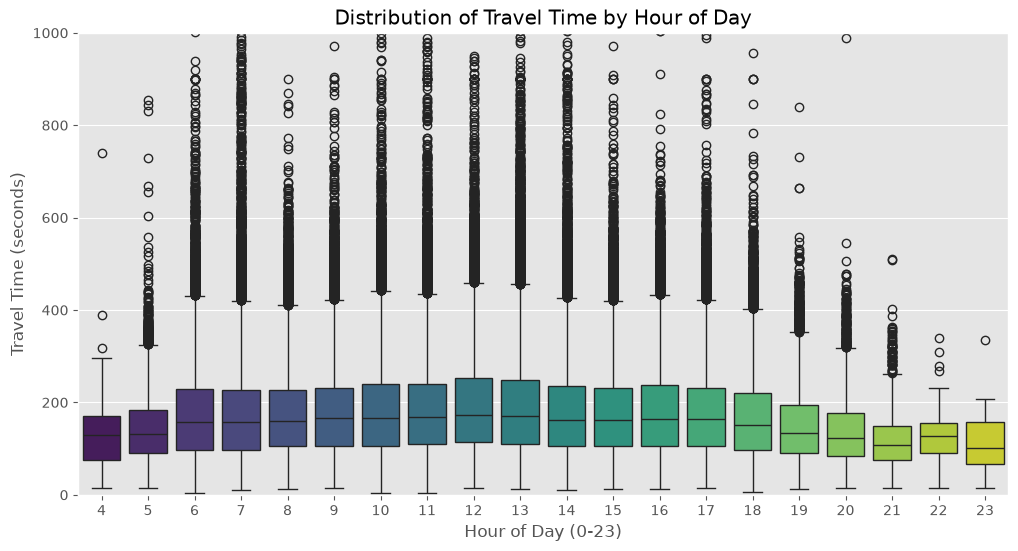

In [3]:
# 2. Boxplot of Travel Time by Hour of Day
# This visually proves if "Rush Hour" actually exists in our data
plt.figure(figsize=(12, 6))
sns.boxplot(x='hour', y='run_time_in_seconds', data=df, palette='viridis')
plt.title('Distribution of Travel Time by Hour of Day')
plt.xlabel('Hour of Day (0-23)')
plt.ylabel('Travel Time (seconds)')
plt.ylim(0, 1000) # Capped for better visibility
plt.show()

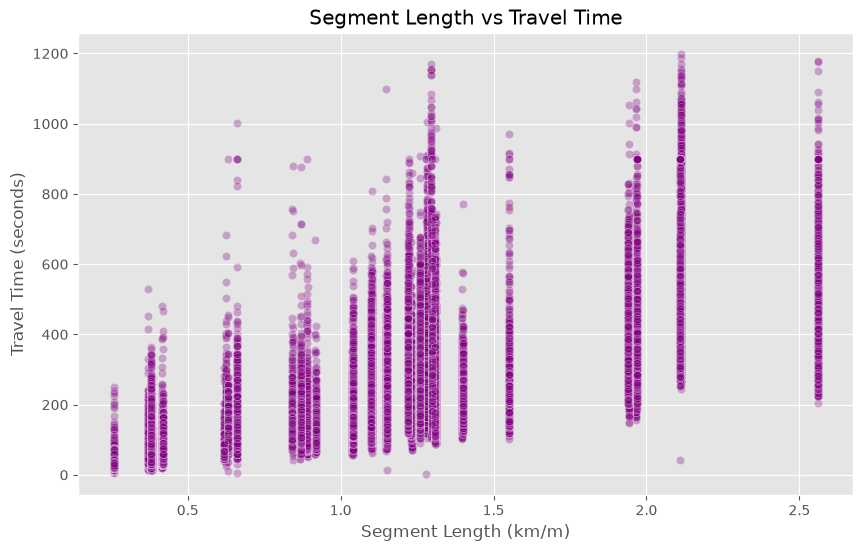

In [4]:
# 3. Scatter Plot: Segment Length vs Travel Time
plt.figure(figsize=(10, 6))
sns.scatterplot(x='length', y='run_time_in_seconds', data=df, alpha=0.3, color='purple')
plt.title('Segment Length vs Travel Time')
plt.xlabel('Segment Length (km/m)')
plt.ylabel('Travel Time (seconds)')
plt.show()

## Part 2: Understanding the Model Output
Let's quickly retrain XGBoost so we can visualize its errors.

In [5]:
# Quick Retrain of XGBoost
X = df.drop(columns=['run_time_in_seconds'])
y = df['run_time_in_seconds']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

xgb_model = xgb.XGBRegressor(n_estimators=100, max_depth=6, random_state=42, n_jobs=-1)
xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_test)

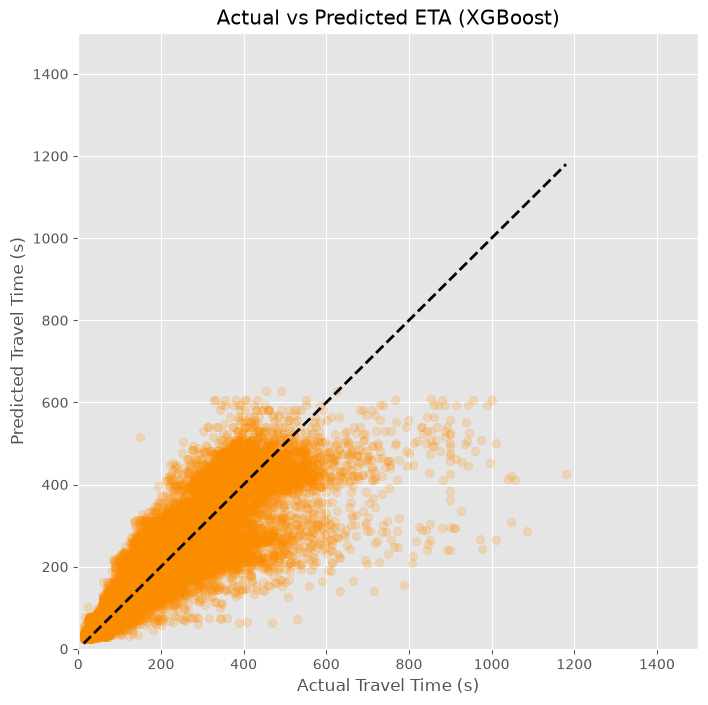

In [6]:
# 4. Actual vs. Predicted Scatter Plot
plt.figure(figsize=(8, 8))
plt.scatter(y_test, xgb_preds, alpha=0.2, color='darkorange')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2) # 45-degree line
plt.title('Actual vs Predicted ETA (XGBoost)')
plt.xlabel('Actual Travel Time (s)')
plt.ylabel('Predicted Travel Time (s)')
plt.xlim(0, 1500)
plt.ylim(0, 1500)
plt.show()

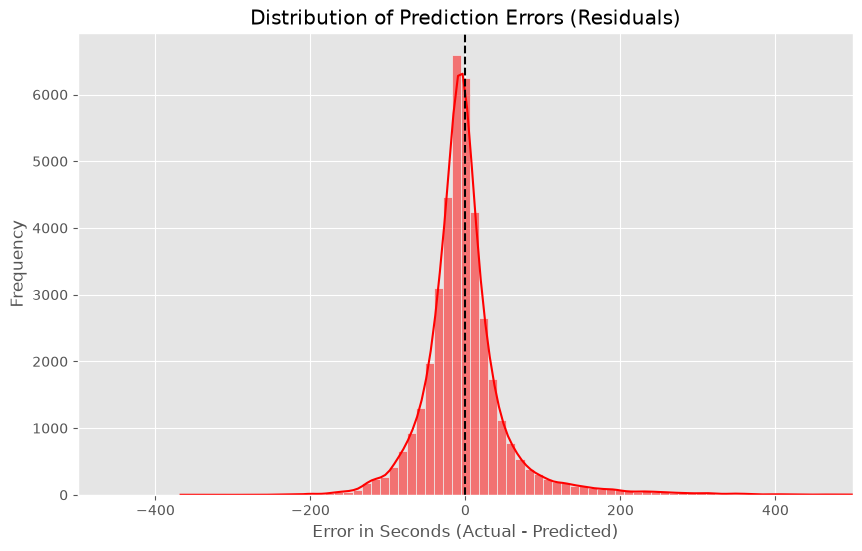

If the curve is centered at 0, our model has no directional bias!
Mean Error (Bias): -0.62 seconds


In [7]:
# 5. Residual (Error) Distribution
residuals = y_test - xgb_preds

plt.figure(figsize=(10, 6))
sns.histplot(residuals, bins=100, kde=True, color='red')
plt.axvline(x=0, color='black', linestyle='--')
plt.title('Distribution of Prediction Errors (Residuals)')
plt.xlabel('Error in Seconds (Actual - Predicted)')
plt.ylabel('Frequency')
plt.xlim(-500, 500)
plt.show()

print("If the curve is centered at 0, our model has no directional bias!")
print(f"Mean Error (Bias): {residuals.mean():.2f} seconds")